In [1]:
# Libraries
!pip install -q wfdb

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats
from scipy.signal import butter, filtfilt
import wfdb

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import nltk
nltk.download("punkt")
nltk.download("stopwords")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.7 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#PART A — TABULAR

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#inspect and clean
print(df.info())
print(df.isnull().sum())

invalid = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                      

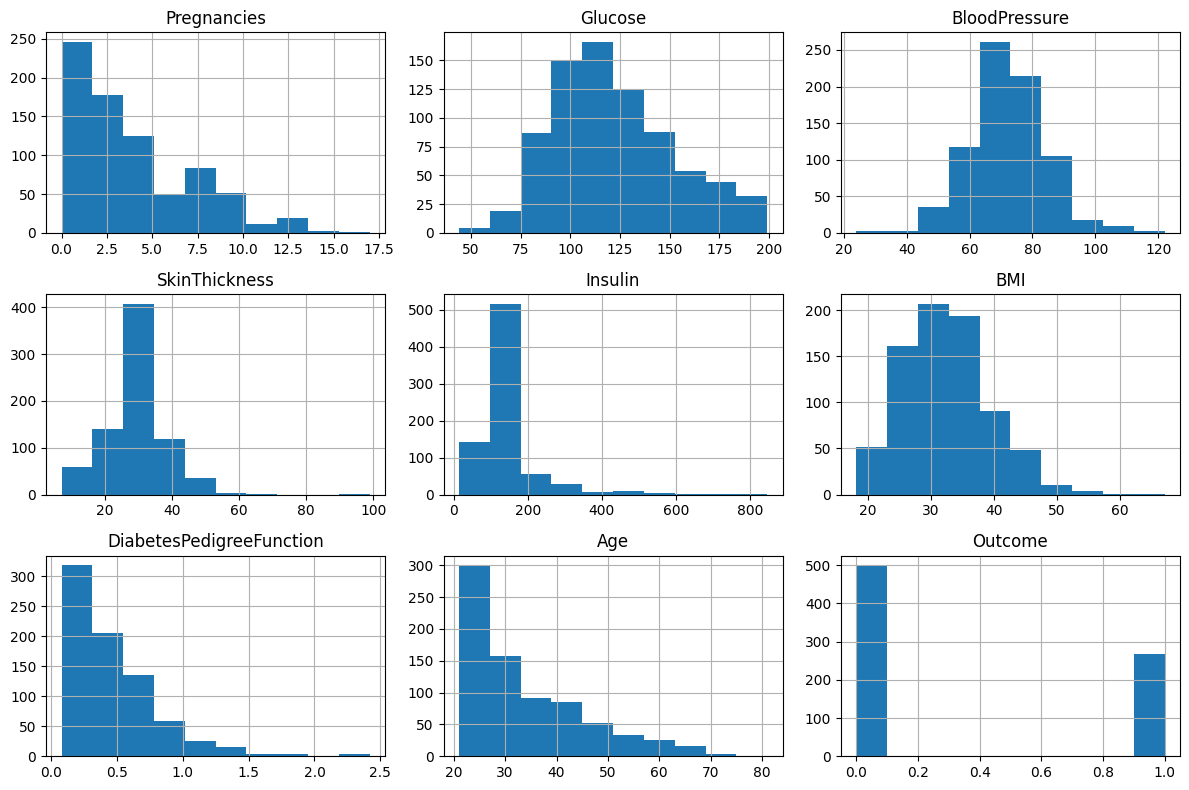

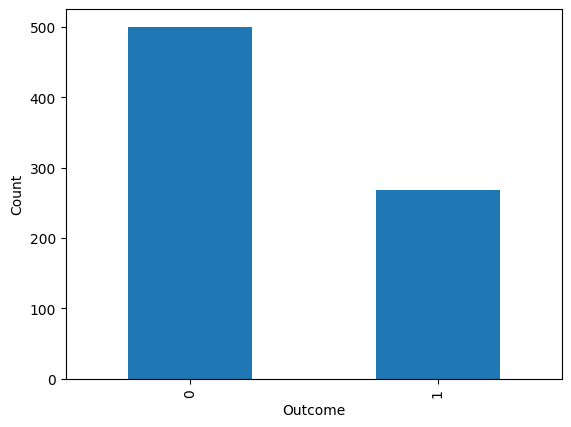

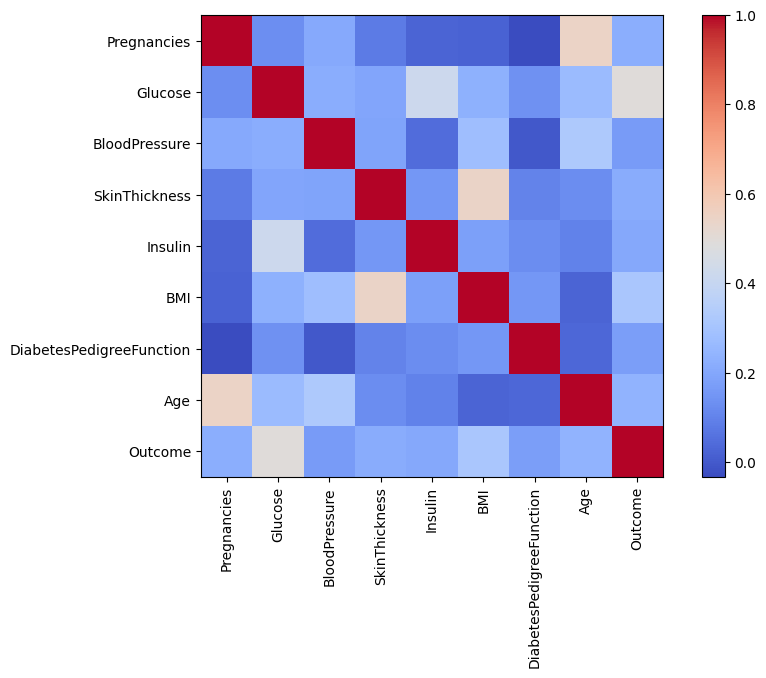

In [4]:
#EDA
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

df["Outcome"].value_counts().plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.show()

In [5]:
#hypothesis testing
g0 = df[df["Outcome"] == 0]["Glucose"]
g1 = df[df["Outcome"] == 1]["Glucose"]

t, p = stats.ttest_ind(g0, g1)

print("t-statistic:", t)
print("p-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

t-statistic: -15.673795182294105
p-value: 3.1287190418423694e-48
Reject H0


In [6]:
#chi square test
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

table = pd.crosstab(
    df["BMI_Category"],
    df["Outcome"]
)

chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Chi-square: 73.13331881767633
p-value: 9.101656268510895e-16
Reject H0


In [7]:
#ANOVA
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[20, 30, 40, 50, 100],
    labels=["21-30", "31-40", "41-50", "51+"]
)

groups = [
    x["Glucose"].values
    for _, x in df.groupby("AgeGroup", observed=True)
]

f, p = stats.f_oneway(*groups)

print("F-statistic:", f)
print("p-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

F-statistic: 19.733198998160084
p-value: 2.5012447956304365e-12
Reject H0


In [10]:
from sklearn.feature_selection import SelectKBest, chi2 as chi2_test

df["Glucose_BMI"] = df["Glucose"] * df["BMI"]
df["Age_BMI"] = df["Age"] * df["BMI"]

X = df.drop(
    columns=["Outcome", "BMI_Category", "AgeGroup"]
)

y = df["Outcome"]

X = X.astype(float)
X = X - X.min()
X = X.clip(lower=0)

selector = SelectKBest(
    score_func=chi2_test,
    k=5
)

X_selected = selector.fit_transform(X, y)

print("Selected features:")
print(X.columns[selector.get_support()].tolist())

Selected features:
['Glucose', 'Insulin', 'Age', 'Glucose_BMI', 'Age_BMI']


In [11]:
#scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df.drop(columns=["Outcome", "BMI_Category", "AgeGroup"])
)

print(X_scaled.shape)

(768, 10)


#PART B — TEXT

In [15]:
url = "https://raw.githubusercontent.com/aneuraz/mtsamplesFR/master/data/mtsamples.csv"

text_df = pd.read_csv(url)

print(text_df.shape)
text_df.head()

(4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [17]:
print(text_df.columns)
print(text_df.isnull().sum())

text_df = text_df.drop_duplicates()
text_df = text_df.dropna(subset=["transcription"])

print(text_df.shape)

Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64
(4966, 6)


In [18]:
print(text_df.columns)
print(text_df.isnull().sum())

text_df = text_df.drop_duplicates()
text_df = text_df.dropna(subset=["transcription"])

Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription           0
keywords             1068
dtype: int64


In [21]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text)
    text = re.sub(r"\b[\w.-]+@[\w.-]+\.\w+\b", " ", text)
    text = re.sub(r"\b\d{3}[-.\s]\d{3}[-.\s]\d{4}\b", " ", text)
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [x for x in tokens if x not in stop_words]
    return " ".join(tokens)

text_df["clean_text"] = text_df["transcription"].apply(clean_text)

text_df[["transcription", "clean_text"]].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,transcription,clean_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective year old white female presents comp...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history difficulty climbing stair...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history present illness seen abc today pleasan...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",mode left atrial enlargement left atrial diame...
4,1. The left ventricular cavity size and wall ...,left ventricular cavity size wall thickness ap...


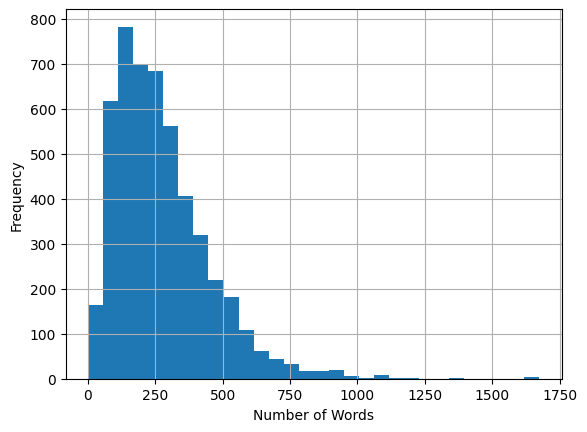

In [22]:
text_df["word_count"] = text_df["clean_text"].str.split().str.len()

text_df["word_count"].hist(bins=30)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [23]:
#tokenizationa nd feature extraction
text_df["tokens"] = text_df["clean_text"].apply(word_tokenize)

vectorizer = TfidfVectorizer(max_features=3000)

X_text = vectorizer.fit_transform(
    text_df["clean_text"]
)

print(X_text.shape)

(4966, 3000)


#PART C — IMAGE

In [25]:
!wget -q https://github.com/probml/chest_xray_kaggle/archive/refs/heads/main.zip -O /content/chest_xray.zip
!unzip -q /content/chest_xray.zip -d /content/
!mv /content/chest_xray_kaggle-main /content/chest_xray

import os
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = "/content/chest_xray"

train_path = IMAGE_PATH + "/train"
test_path = IMAGE_PATH + "/test"

print(os.listdir(train_path))
print("Train Normal:", len(os.listdir(train_path + "/NORMAL")))
print("Train Pneumonia:", len(os.listdir(train_path + "/PNEUMONIA")))
print("Test Normal:", len(os.listdir(test_path + "/NORMAL")))
print("Test Pneumonia:", len(os.listdir(test_path + "/PNEUMONIA")))

['NORMAL', '.DS_Store', 'PNEUMONIA']
Train Normal: 1342
Train Pneumonia: 3876
Test Normal: 234
Test Pneumonia: 390


In [27]:
classes = [c for c in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, c))]

print(classes)

for c in classes:
    print(c, len(os.listdir(os.path.join(train_path, c))))

['NORMAL', 'PNEUMONIA']
NORMAL 1342
PNEUMONIA 3876


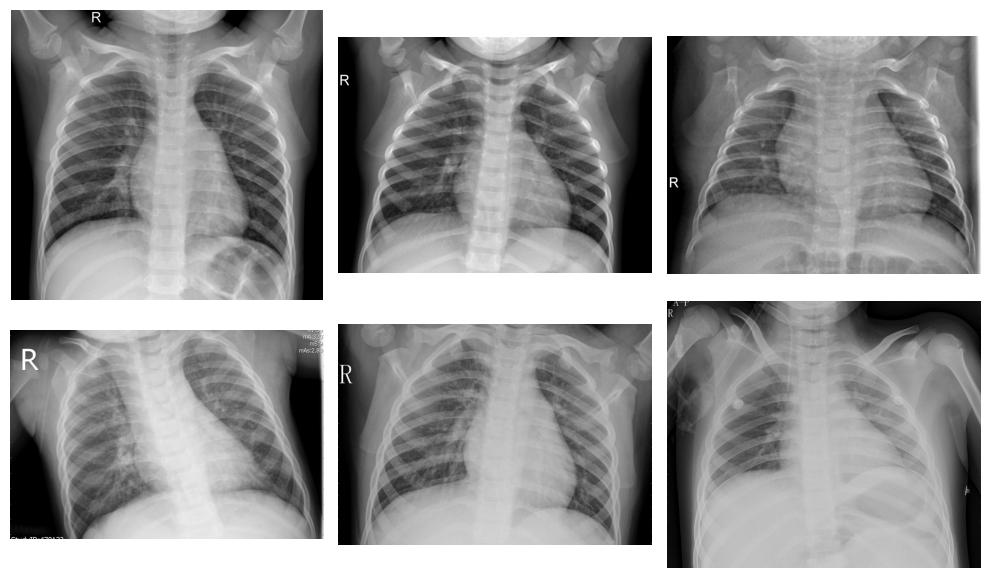

In [28]:
files = []

for c in classes:
    folder = train_path + "/" + c
    for f in os.listdir(folder)[:3]:
        files.append(folder + "/" + f)

plt.figure(figsize=(10, 6))

for i, f in enumerate(files[:6]):
    img = Image.open(f)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
img = Image.open(files[0])

print(img.getexif())

img = img.convert("RGB")
img.save("/content/anonymized_xray.jpg")

{34665: 26}


In [30]:
IMG_SIZE = (224, 224)

datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="binary"
)

print(train_generator.class_indices)

Found 5216 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}


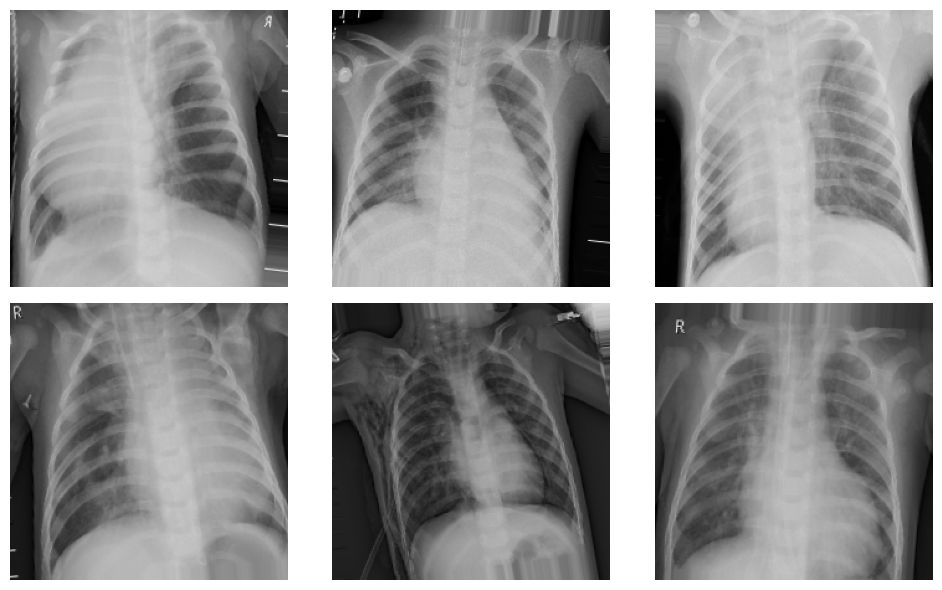

In [31]:
#check augmentation
images, labels = next(train_generator)

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

#PART D — SIGNAL

In [32]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

ecg = record.p_signal[:, 0]
fs = record.fs

print("Sampling frequency:", fs)
print("Samples:", len(ecg))

Sampling frequency: 360
Samples: 650000


Mean: -0.3062989769230769
Std: 0.19319954213721688
Min: -2.715
Max: 1.435


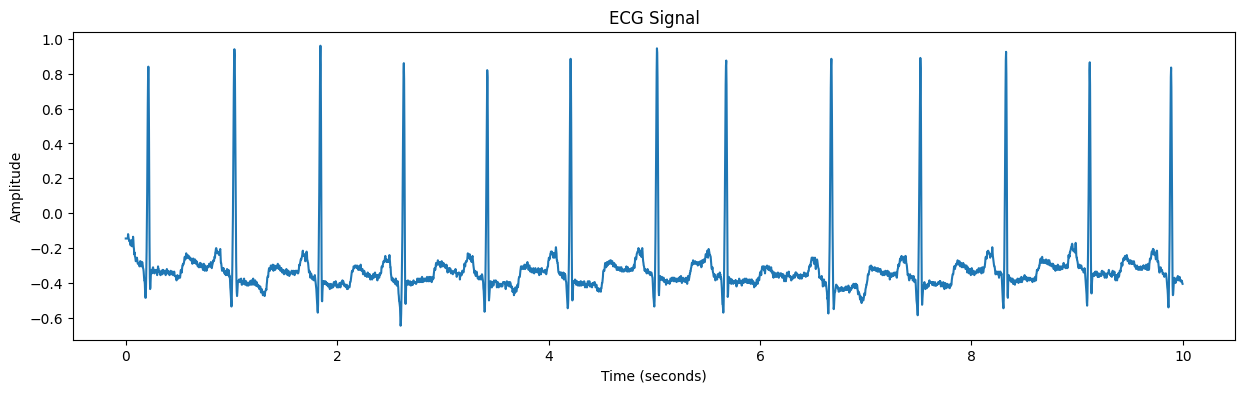

In [33]:
print("Mean:", np.mean(ecg))
print("Std:", np.std(ecg))
print("Min:", np.min(ecg))
print("Max:", np.max(ecg))

time = np.arange(len(ecg)) / fs

samples = int(10 * fs)

plt.figure(figsize=(15, 4))

plt.plot(
    time[:samples],
    ecg[:samples]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal")

plt.show()

In [34]:
#noise removal
def bandpass(signal, low, high, fs):
    nyquist = fs / 2
    b, a = butter(
        4,
        [low / nyquist, high / nyquist],
        btype="band"
    )
    return filtfilt(b, a, signal)

filtered_ecg = bandpass(
    ecg,
    0.5,
    40,
    fs
)

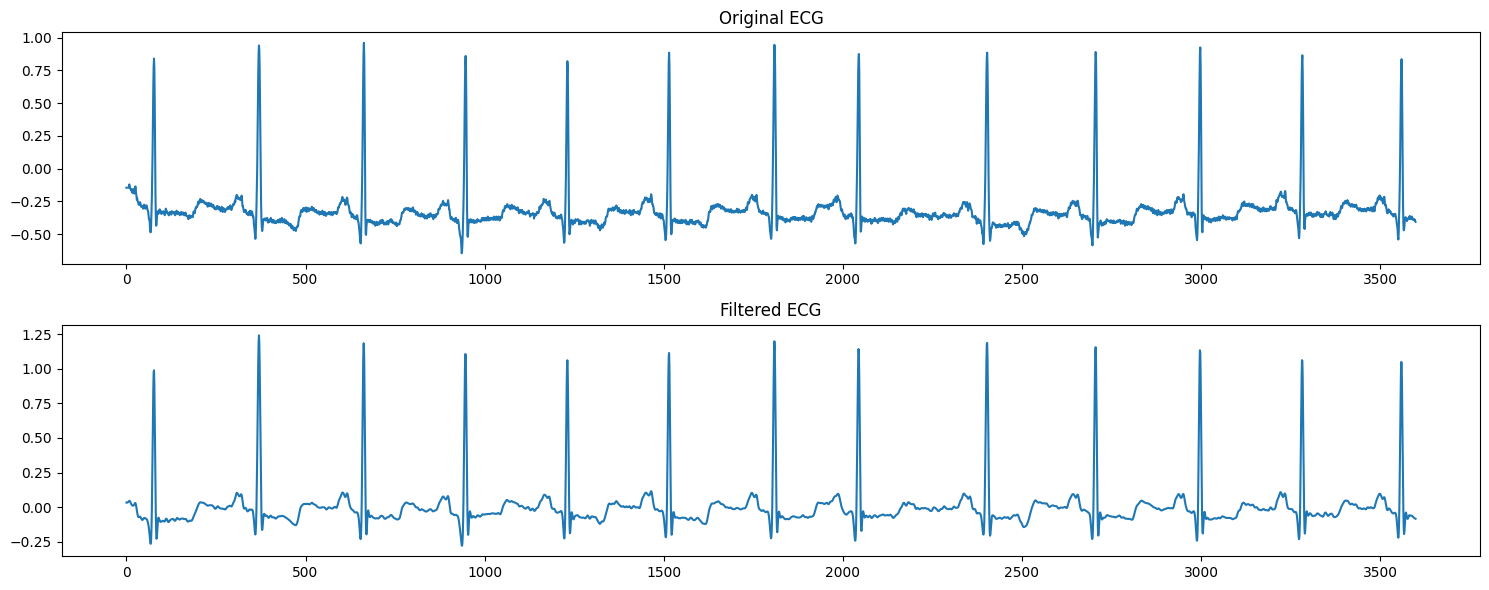

In [35]:
#original vs filter ECG
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(ecg[:samples])
plt.title("Original ECG")

plt.subplot(2, 1, 2)
plt.plot(filtered_ecg[:samples])
plt.title("Filtered ECG")

plt.tight_layout()
plt.show()

In [36]:
#signal windowing
window_size = int(5 * fs)

n = len(filtered_ecg) // window_size

ecg_windows = np.array([
    filtered_ecg[
        i * window_size:
        (i + 1) * window_size
    ]
    for i in range(n)
])

print(ecg_windows.shape)

(361, 1800)


In [37]:
#signal feature extraction
features = pd.DataFrame({
    "mean": np.mean(ecg_windows, axis=1),
    "std": np.std(ecg_windows, axis=1),
    "min": np.min(ecg_windows, axis=1),
    "max": np.max(ecg_windows, axis=1),
    "range": np.ptp(ecg_windows, axis=1),
    "rms": np.sqrt(np.mean(ecg_windows ** 2, axis=1))
})

features.head()

,mean,std,min,max,range,rms
0,-0.003194,0.159633,-0.278717,1.240993,1.519710,0.159665
1,0.002878,0.170659,-0.242458,1.198003,1.440461,0.170683
2,-0.001033,0.157981,-0.256442,1.168682,1.425124,0.157984
3,-0.001912,0.168449,-0.245797,1.258394,1.504191,0.168460
4,0.000060,0.170082,-0.261643,1.316599,1.578243,0.170082


In [38]:
ecg_tensor = np.expand_dims(
    ecg_windows,
    axis=-1
)

print(ecg_tensor.shape)

(361, 1800, 1)


In [39]:
#save processed data
df.to_csv(
    "cleaned_pima_diabetes.csv",
    index=False
)

text_df.to_csv(
    "cleaned_medical_transcriptions.csv",
    index=False
)

features.to_csv(
    "ecg_features.csv",
    index=False
)

np.save(
    "ecg_windows.npy",
    ecg_windows
)

print("Assignment completed.")

Assignment completed.
